# Week 1 - Day 4

# Data Visualization using Matplotlib, Seaborn and Plotly

## AI/ML Internship Program

### Objective

The objective of this task is to learn how to visualize data using different Python visualization libraries. Data visualization helps identify trends, distributions, relationships, and patterns in datasets.

### Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

### Dataset Used

Titanic Dataset from Kaggle

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_style("whitegrid")

In [8]:
df = pd.read_csv("../dataset/cleaned_titanic.csv")
df = pd.read_csv("../dataset/Titanic-Dataset.csv")

df.head()
print(df.head())
print(df.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [9]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

Missing Values:
PassengerId      0
Survived  

# Dataset Overview

The Titanic dataset contains passenger information including age, gender, passenger class, fare, and survival status.

The dataset consists of 891 rows and 12 columns.

Some columns contain missing values which will be analyzed during visualization.

# Chart 1: Age Distribution Histogram

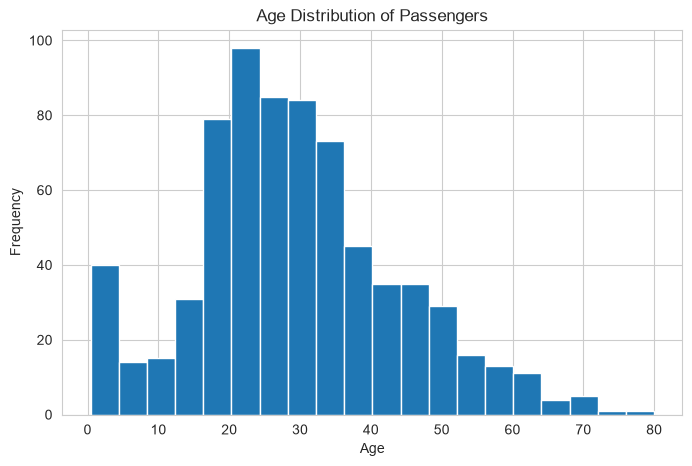

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"].dropna(), bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Most passengers were between 20 and 40 years old.

Very few passengers were older than 70 years.

The age distribution is slightly right-skewed.

# Chart 2: Survival Count by Passenger Class

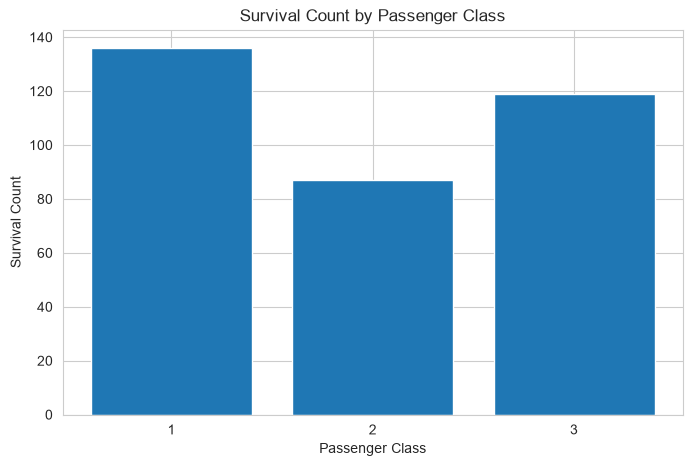

In [11]:
survival_class = df.groupby("Pclass")["Survived"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    survival_class.index.astype(str),
    survival_class.values
)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Count")

plt.show()

### Interpretation

First-class passengers had the highest survival count.

Third-class passengers had the lowest survival count.

Passenger class had a significant impact on survival chances.

# Chart 3: Fare Distribution by Passenger Class

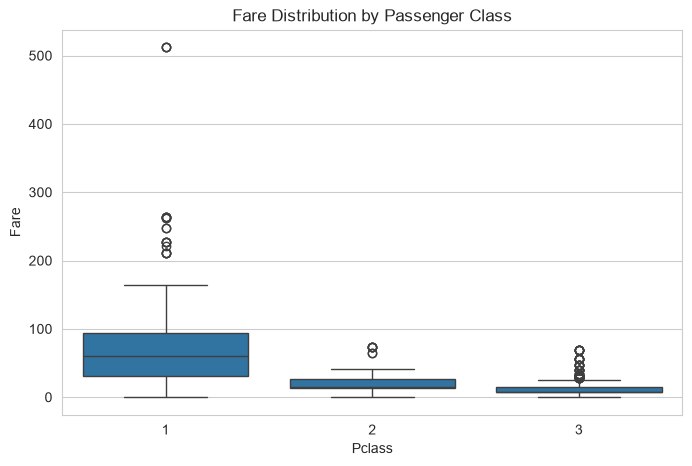

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare Distribution by Passenger Class")

plt.show()

### Interpretation

Several fare outliers are visible.

Passengers in first class generally paid much higher fares.

# Chart 4: Correlation Heatmap

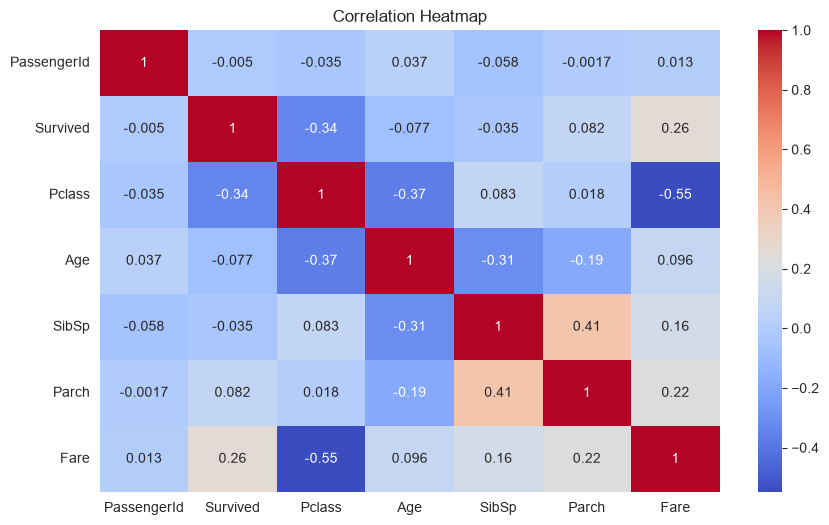

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap shows relationships between numerical variables.

Some variables have positive correlation while others have weak relationships.

# Chart 5: Age vs Fare

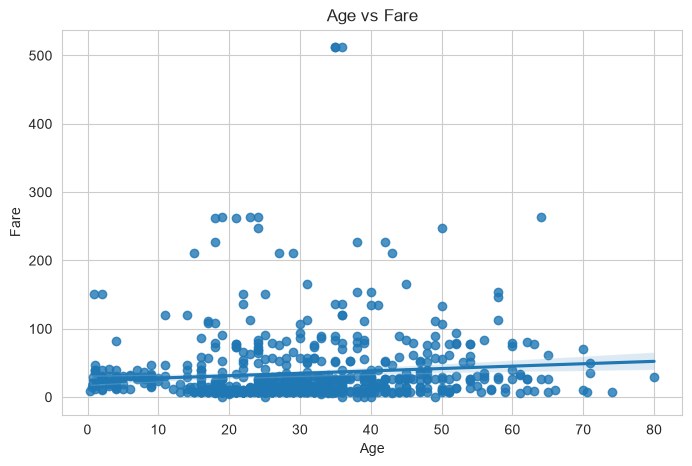

In [14]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Age",
    y="Fare"
)

plt.title("Age vs Fare")

plt.show()

### Interpretation

A weak positive relationship exists between age and fare.

Older passengers sometimes paid higher fares.

# Chart 6: Fare Distribution Across Passenger Classes

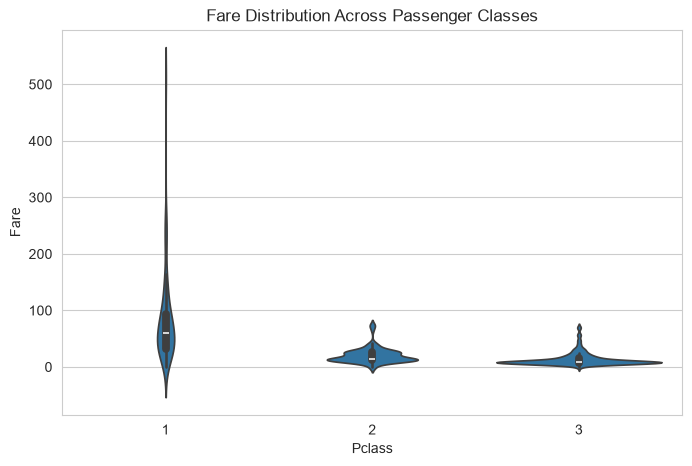

In [15]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare Distribution Across Passenger Classes")

plt.show()

### Interpretation

The fare distribution varies significantly across passenger classes.

First-class passengers generally paid higher fares.

# Chart 7: Interactive Survival Count by Passenger Class

In [16]:
plotly_bar = (
    df.groupby("Pclass")["Survived"]
      .sum()
      .reset_index()
)

fig = px.bar(
    plotly_bar,
    x="Pclass",
    y="Survived",
    title="Interactive Survival Count by Passenger Class"
)

fig.show()

### Interpretation

The interactive chart allows users to hover over bars and inspect exact values.

# Chart 8: Age vs Fare by Gender

In [17]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Sex",
    hover_data=["Pclass"],
    title="Age vs Fare by Gender"
)

fig.show()

### Interpretation

Different fare patterns can be observed among male and female passengers.

Gender appears to influence travel class and fare distribution.

# Key Findings

1. Most passengers were between 20 and 40 years old.

2. Passenger class significantly influenced survival rates.

3. First-class passengers generally paid higher fares.

4. Several fare outliers were detected.

5. Age showed only a weak relationship with fare.

6. Interactive charts provided better insight into passenger behavior.

In [18]:
print("Day 4 Visualization Task Completed Successfully!")

Day 4 Visualization Task Completed Successfully!


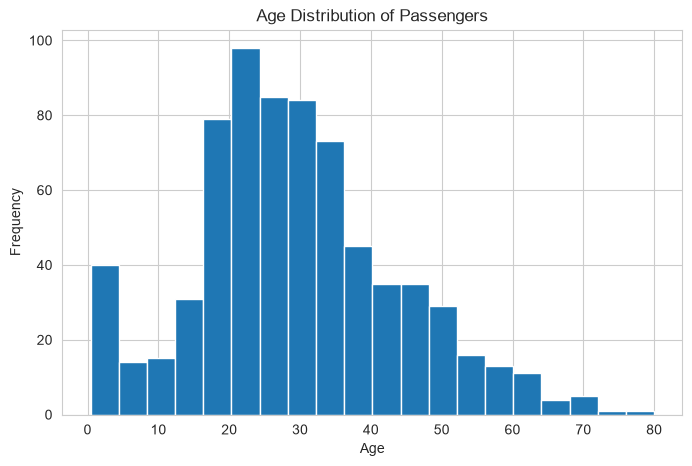

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"].dropna(), bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig("../output/chart1_histogram.png")

plt.show()

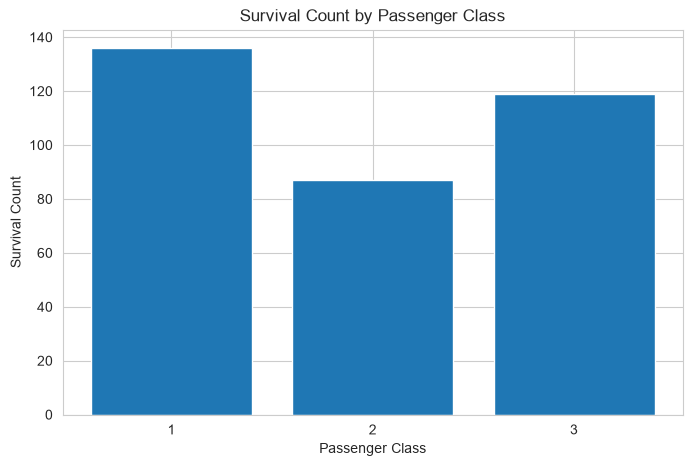

In [20]:
survival_class = df.groupby("Pclass")["Survived"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    survival_class.index.astype(str),
    survival_class.values
)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Count")

plt.savefig("../output/chart2_bar_chart.png")

plt.show()

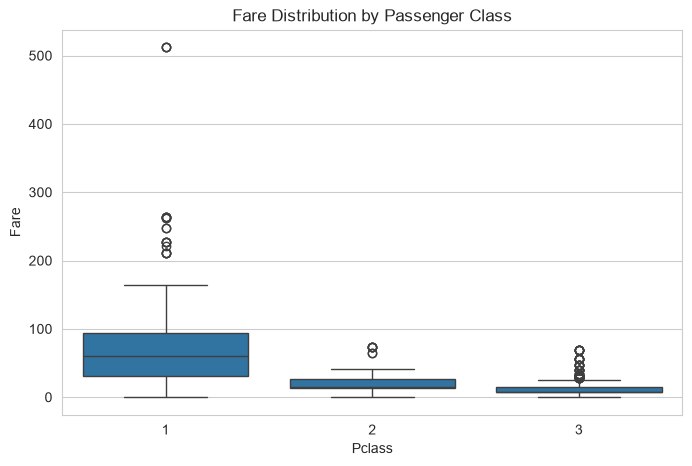

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare Distribution by Passenger Class")

plt.savefig("../output/chart3_boxplot.png")

plt.show()

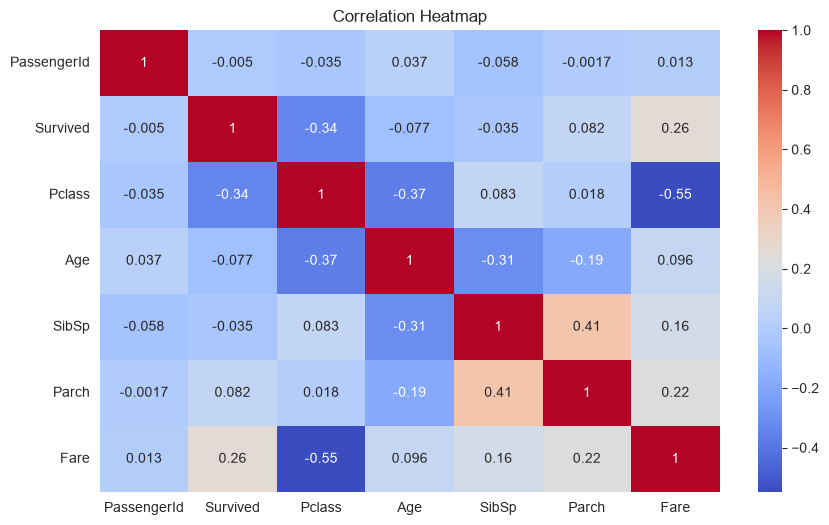

In [22]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../output/chart4_heatmap.png")

plt.show()

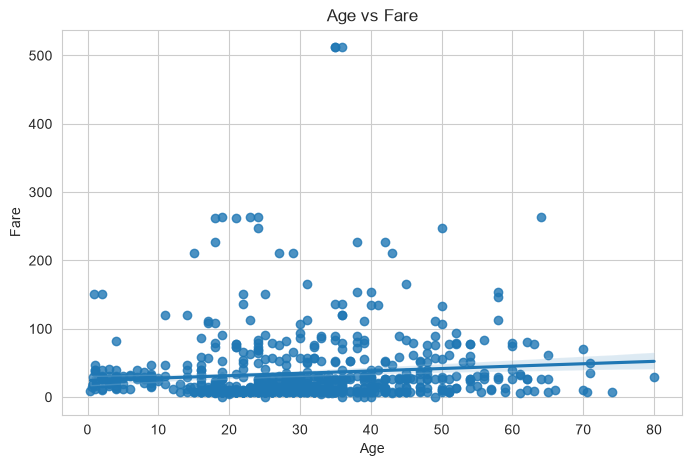

In [23]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Age",
    y="Fare"
)

plt.title("Age vs Fare")

plt.savefig("../output/chart5_scatterplot.png")

plt.show()

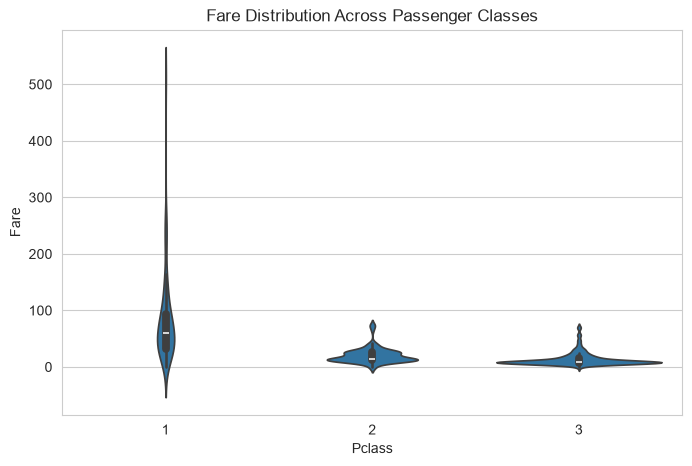

In [24]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare Distribution Across Passenger Classes")

plt.savefig("../output/chart6_violinplot.png")

plt.show()